# Use case 1 (research), worked: rebuild my first paper, from prompts only

**STAI-X 2026 SC01 guest segment. Shihao Yang, Georgia Tech ISyE.**

In 2015, as a second-year PhD student in this department, my first paper was [ARGO](https://www.pnas.org/doi/10.1073/pnas.1515373112) (Yang, Santillana, Kou, *PNAS* 2015): use Google search volume, plus the disease's own history, to nowcast influenza. It took the better part of a year.

This notebook rebuilds the same idea for dengue in Mexico. **I wrote no Python.** Every code cell is what a coding agent produced from the prompt above it.

**Nothing here is pre-supplied.** Both data sources are downloaded live in the next two cells: search interest from Google Trends, case counts from [OpenDengue](https://opendengue.org/). That is deliberate. Fetching data is where agents are strongest and where the wow lands, and it is also where the most interesting mistakes hide.

This is the **worked version**. To run it yourself, start from [`01_research_dengue.ipynb`](01_research_dengue.ipynb), which has the same prompts and empty cells.

## Prompt 0a: get the search data

> *Use the `pytrends` package to download monthly Google search interest in Mexico for `dengue`, `sintomas de dengue`, `mosquito` and `dengue sintomas`, over the longest window it will give me in one request. Return a tidy DataFrame indexed by date. Save it to `data/gt_dengue_mx.csv`.*

In [1]:
import os, io, zipfile, urllib.request
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
os.makedirs("../data", exist_ok=True)
TERMS = ["dengue", "sintomas de dengue", "mosquito", "dengue sintomas"]
GT_CSV = "../data/gt_dengue_mx.csv"

def fetch_google_trends():
    from pytrends.request import TrendReq
    # NOTE: no retries=/backoff_factor= here. See the cell below.
    py = TrendReq(hl="en-US", tz=360)
    py.build_payload(TERMS, timeframe="2004-01-01 2024-12-31", geo="MX")
    out = py.interest_over_time().drop(columns=["isPartial"])
    out.index.name = "date"
    return out

try:
    gt = fetch_google_trends()
    gt.to_csv(GT_CSV)
    print("Downloaded live from Google Trends.")
except Exception as e:
    gt = pd.read_csv(GT_CSV, parse_dates=["date"]).set_index("date")
    print(f"Live fetch failed ({type(e).__name__}); using the cached copy committed to the repo.")

print(f"{len(gt)} months, {gt.index.min():%Y-%m} to {gt.index.max():%Y-%m}")
gt.tail(3)

Downloaded live from Google Trends.
252 months, 2004-01 to 2024-12


,dengue,sintomas de dengue,mosquito,dengue sintomas
date,,,,
2024-10-01,100,7,6,19
2024-11-01,78,6,5,16
2024-12-01,33,3,4,6


### The first thing that went wrong

The agent's first attempt was this, and it is exactly what I would have written:

```python
TrendReq(hl="en-US", tz=360, retries=3, backoff_factor=0.5)
```

It crashes:

```
TypeError: Retry.__init__() got an unexpected keyword argument 'method_whitelist'
```

`pytrends` passes `method_whitelist` to urllib3, which renamed that argument to `allowed_methods` in version 2. Every tutorial online still shows the `retries=` form, because they were written before the rename.

Worth noticing **how** it got fixed: the agent ran the code, read the traceback, and dropped the argument, all without me. That loop is the entire reason to use a terminal agent rather than an autocomplete pane. But also notice the cost: retries are now gone, so a rate-limited request fails outright instead of backing off. **The agent fixed the error, not the intent.** Nobody said so.

## Prompt 0b: get the case counts

> *Download the OpenDengue national extract (V1.3), pull out Mexico's weekly records, and aggregate them to monthly totals. Drop any month that does not have at least 4 weeks of data. Save to `data/opendengue_mexico_monthly.csv`.*

In [2]:
OD_URL = ("https://raw.githubusercontent.com/OpenDengue/master-repo/"
          "main/data/releases/V1.3/National_extract_V1_3.zip")
OD_CSV = "../data/opendengue_mexico_monthly.csv"

def fetch_opendengue():
    with urllib.request.urlopen(OD_URL, timeout=120) as r:
        z = zipfile.ZipFile(io.BytesIO(r.read()))
    raw = pd.read_csv(z.open(z.namelist()[0]),
                      parse_dates=["calendar_start_date", "calendar_end_date"])
    mx = raw[(raw.adm_0_name.str.upper() == "MEXICO") & (raw.T_res == "Week")].copy()
    # assign each week to the month containing its midpoint
    mid = mx.calendar_start_date + (mx.calendar_end_date - mx.calendar_start_date) / 2
    mx["month"] = mid.values.astype("datetime64[M]")
    g = mx.groupby("month").agg(cases=("dengue_total", "sum"),
                                weeks=("dengue_total", "size"),
                                defn=("case_definition_standardised",
                                      lambda s: "/".join(sorted(set(s.str.lower())))))
    return g[g.weeks >= 4]

try:
    od = fetch_opendengue()
    od.to_csv(OD_CSV)
    print("Downloaded live from OpenDengue.")
except Exception as e:
    od = pd.read_csv(OD_CSV, parse_dates=["month"]).set_index("month")
    print(f"Live fetch failed ({type(e).__name__}); using the cached copy.")

cases_all = od["cases"]
print(f"{len(od)} monthly observations, {od.index.min():%Y-%m} to {od.index.max():%Y-%m}")
od.head(3)

Downloaded live from OpenDengue.
156 monthly observations, 2003-01 to 2023-12


,cases,weeks,defn
month,,,
2003-01-01,40.0,4,confirmed
2003-02-01,111.0,4,confirmed
2003-03-01,100.0,4,confirmed


## The prompt that matters most

Before touching a model, ask what came back:

> *Check the coverage of what you just downloaded. Are the months contiguous? Compare the overlapping period against `data/MX_Dengue_trends.csv`, the file I already had. Do the two agree?*

In [3]:
# 1. contiguous runs
idx = cases_all.index
runs, start = [], idx[0]
for a, b in zip(idx, idx[1:]):
    if (b.year - a.year) * 12 + (b.month - a.month) != 1:
        runs.append((start, a)); start = b
runs.append((start, idx[-1]))

print("Contiguous runs in the downloaded case data:")
for a, b in runs:
    n = (b.year - a.year) * 12 + (b.month - a.month) + 1
    print(f"   {a:%Y-%m} to {b:%Y-%m}   {n:>3} months   "
          f"[{od.loc[a:b,'defn'].mode()[0]}]")

# 2. agreement with the file I already had
bundled = pd.read_csv("../data/MX_Dengue_trends.csv", parse_dates=["Date"]).set_index("Date")
cmp = pd.DataFrame({"OpenDengue": cases_all, "bundled file": bundled["Dengue CDC"]}).dropna()
d = (cmp["bundled file"] - cmp["OpenDengue"]).abs()
pct = d / cmp["bundled file"].replace(0, np.nan) * 100
print(f"\nOverlap with the file I already had: {len(cmp)} months")
print(f"   correlation                : {cmp['OpenDengue'].corr(cmp['bundled file']):.3f}")
print(f"   ratio of totals            : {cmp['bundled file'].sum() / cmp['OpenDengue'].sum():.2f}x")
print(f"   median abs month-on-month  : {pct.median():.0f}%")
print(f"   months differing over 50%  : {(pct > 50).sum()} of {len(cmp)}")
print(f"   worst single month         : {d.max():,.0f} cases")
cmp.head(4)

Contiguous runs in the downloaded case data:
   2003-01 to 2007-12    60 months   [confirmed]
   2015-01 to 2019-12    60 months   [total]
   2021-01 to 2023-12    36 months   [total]

Overlap with the file I already had: 48 months
   correlation                : 0.902
   ratio of totals            : 1.07x
   median abs month-on-month  : 30%
   months differing over 50%  : 13 of 48
   worst single month         : 4,468 cases


,OpenDengue,bundled file
2004-01-01,31.0,98.0
2004-02-01,46.0,41.0
2004-03-01,55.0,53.0
2004-04-01,58.0,92.0


### Two things the download got right, and two it hid

I asked for "all available monthly dengue case counts in Mexico." I got a table. It looked complete. It was not.

**There are holes.** The record is not one series, it is three islands: roughly 2003-2007, 2015-2019, and 2021-2023. The years 2008-2014 are simply absent, and so is 2020. Nothing in the download announces this. A `df.head()` looks perfect, a plot looks plausible, and a rolling-window model would happily train across a seven-year gap as though the months were adjacent.

**The units change between islands.** The early island is Ministry of Health **confirmed** cases; the later one is WHO/PAHO **total** cases. Those are different quantities, silently concatenated into one column.

**And two "official" sources disagree about the same months.** Against the curated file I already had, the overlap correlates at 0.90 and the four-year totals match within 7%, which looks like agreement. Month by month it is not: the median absolute difference is **30%**, a quarter of the months differ by more than half, and the worst single month is off by 4,468 cases. Aggregate agreement was hiding month-level disagreement, and monthly is the resolution I am about to model at.

Neither fact is a bug in OpenDengue, which documents both. Both are invisible unless you go looking, and **the agent had no reason to look.** I asked for the data, and the data is what I got.

> This is the single lesson I would keep if I could keep only one. The agent closes the gap between having an idea and seeing a number, almost completely. It does not close the gap between seeing a number and believing it. That gap is still the job.

So: **2015-2019**, sixty contiguous months on one consistent definition. Chosen by me, not by the agent.

Modeling window: 60 months, 2015-01 to 2019-12
Mean 13,111 cases/month, peak 84,343


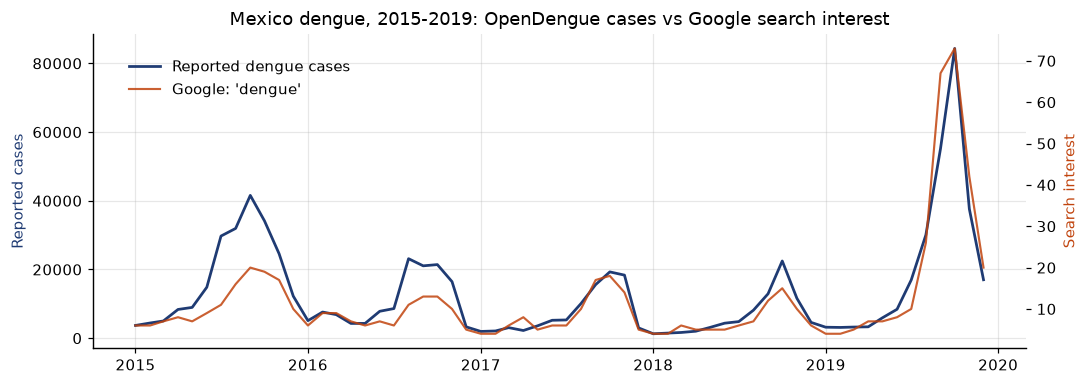


Correlation with cases:
dengue sintomas       0.921
dengue                0.913
sintomas de dengue    0.870
mosquito              0.688


In [4]:
LO, HI, WINDOW = "2015-01-01", "2019-12-01", 24
cases = cases_all.loc[LO:HI]
search = gt.loc[cases.index]
print(f"Modeling window: {len(cases)} months, {cases.index.min():%Y-%m} to {cases.index.max():%Y-%m}")
print(f"Mean {cases.mean():,.0f} cases/month, peak {cases.max():,.0f}")

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(cases.index, cases.values, color="#1f3b73", lw=1.8, label="Reported dengue cases")
ax.set_ylabel("Reported cases", color="#1f3b73")
ax2 = ax.twinx()
ax2.plot(search.index, search["dengue"], color="#c1440e", lw=1.4, alpha=.85, label="Google: 'dengue'")
ax2.set_ylabel("Search interest", color="#c1440e"); ax2.grid(False)
ax.set_title("Mexico dengue, 2015-2019: OpenDengue cases vs Google search interest")
fig.legend(loc="upper left", bbox_to_anchor=(.11, .87), frameon=False)
plt.tight_layout(); plt.show()

print("\nCorrelation with cases:")
print(search.corrwith(cases).sort_values(ascending=False).round(3).to_string())

## Prompt 1: the honest baseline

Reproduce what a reasonable person would have done before any of this was fashionable.

> *Fit ordinary least squares of cases on the single `dengue` search column, training only on the first 24 months. Predict the rest from that frozen fit. Do not refit on anything later.*

That last sentence is load-bearing. Leakage is the most common way this kind of analysis goes quietly wrong, and an agent optimizing for a good-looking number will refit if you let it.

In [5]:
from sklearn.linear_model import LinearRegression, LassoCV

train_idx = cases.index[:WINDOW]
ols = LinearRegression().fit(search.loc[train_idx, ["dengue"]], cases.loc[train_idx])
print(f"Fitted on {len(train_idx)} months ({train_idx.min():%Y-%m} to {train_idx.max():%Y-%m}), never refit.")
print(f"cases = {ols.intercept_:,.0f} + {ols.coef_[0]:,.0f} x search")

Fitted on 24 months (2015-01 to 2016-12), never refit.
cases = -9,449 + 2,422 x search


## Prompt 2: now make it ARGO

> *Now build the ARGO model from Yang, Santillana and Kou (PNAS 2015). Work in log space. Regress log cases on the logs of all four search terms plus three autoregressive lags of log cases. Use L1 regularization with a cross-validated penalty, and retrain on a rolling 24-month window at every step so the model only ever sees the past. Fit two references on the identical rolling scheme: autoregression only, and search only. Return predictions on the original case scale.*

Two structural ideas carry ARGO and both are in that paragraph: **autoregression** (yesterday's dengue predicts today's) and **dynamic training** (the search-to-disease relationship drifts, so keep refitting).

In [6]:
L = np.log1p(search); L.columns = [f"log_{c.replace(' ','_')}" for c in search.columns]
log_cases = np.log1p(cases)
for j in (1, 2, 3):
    L[f"log_cases_lag{j}"] = log_cases.shift(j)

X = L.dropna(); Y = log_cases.loc[X.index]
AR_COLS = [c for c in X.columns if c.startswith("log_cases_lag")]
GT_COLS = [c for c in X.columns if c not in AR_COLS]

def rolling_forecast(cols, penalized=True):
    # Refit on the previous WINDOW months at each step; predict one month ahead.
    out = {}
    for pos, t in enumerate(X.index):
        if pos < WINDOW:
            continue
        past = X.index[pos - WINDOW:pos]                  # strictly before t
        model = (LassoCV(cv=5, max_iter=50000) if penalized and len(cols) > 1
                 else LinearRegression()).fit(X.loc[past, cols], Y.loc[past])
        out[t] = float(model.predict(X.loc[[t], cols])[0])
    return np.expm1(pd.Series(out))

pred_ar   = rolling_forecast(AR_COLS, penalized=False)
pred_gt   = rolling_forecast(GT_COLS)
pred_argo = rolling_forecast(AR_COLS + GT_COLS)

window = pred_argo.index
truth = cases.loc[window]
pred_static = pd.Series(ols.predict(search.loc[window, ["dengue"]]), index=window)
print(f"Evaluated on {len(window)} months: {window.min():%Y-%m} to {window.max():%Y-%m}")

Evaluated on 33 months: 2017-04 to 2019-12


## Check it again: what did it decide for me this time?

The agent wrote `np.log1p`. I asked for logs, not `log1p`. So it made a choice on my behalf and did not mention it. **Was it entitled to?**

In [7]:
z = (search == 0).sum()
print("Exact zeros in each search column (of 60 months):\n")
for c in search.columns:
    print(f"  {c:<22} {z[c]:>3}  ({z[c]/len(search)*100:>3.0f}% of the record)")
bad = np.isinf(np.log(search["sintomas de dengue"])).sum()
print(f"\nPlain log() of 'sintomas de dengue' would produce {bad} non-finite values.")

Exact zeros in each search column (of 60 months):

  dengue                   0  (  0% of the record)
  sintomas de dengue      24  ( 40% of the record)
  mosquito                 0  (  0% of the record)
  dengue sintomas          0  (  0% of the record)

Plain log() of 'sintomas de dengue' would produce 24 non-finite values.


/Users/shihaoyang/Workspace/staix2026sc1/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


There it is. `sintomas de dengue` is exactly zero in **40% of months**, so plain `log` would have produced negative infinity and the fit would have died. The agent substituted `log1p` and moved on.

Two things are true at once:

1. **The patch was correct.** `log1p` is the standard fix and it is what I would have done.
2. **It was never surfaced.** Nothing in the output said "your data has structural zeros."

The second fact is the finding. Those zeros are not a numerical nuisance, they are a *measurement* fact: Google Trends thresholds low-volume queries to zero. Forty percent of that column is **not a low value, it is an absent value**. That changes what the model can honestly claim, and no amount of prompting produces that sentence. It comes from knowing the data source.

## Prompt 3: score everything against each other

> *Build one comparison table over the common evaluation window: RMSE, MAE and correlation for the static baseline, the autoregression-only model, the search-only model, and ARGO. Add a column giving each model's RMSE relative to the autoregression benchmark. Then plot ARGO against the truth over time.*

In [8]:
def score(pred):
    p = np.asarray(pred.loc[window], float); t = np.asarray(truth, float)
    return {"RMSE": np.sqrt(np.mean((t - p) ** 2)), "MAE": np.mean(np.abs(t - p)),
            "Corr": np.corrcoef(t, p)[0, 1]}

table = pd.DataFrame({
    "Static OLS, 1 term, frozen fit":     score(pred_static),
    "AR(3), dynamic 24-mo window":        score(pred_ar),
    "Search only, LASSO, dynamic":        score(pred_gt),
    "ARGO (search + AR, LASSO, dynamic)": score(pred_argo),
}).T
table["RMSE vs AR(3)"] = table["RMSE"] / table.loc["AR(3), dynamic 24-mo window", "RMSE"]

display(table.style.format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}",
                            "Corr": "{:.3f}", "RMSE vs AR(3)": "{:.3f}"})
             .set_caption(f"Out-of-sample, {len(window)} months, mean {truth.mean():,.0f} cases/month"))

,RMSE,MAE,Corr,RMSE vs AR(3)
"Static OLS, 1 term, frozen fit","25,333","11,267",0.972,2.375
"AR(3), dynamic 24-mo window","10,666","5,615",0.798,1.000
"Search only, LASSO, dynamic","19,454","6,353",0.874,1.824
"ARGO (search + AR, LASSO, dynamic)","9,566","4,506",0.968,0.897


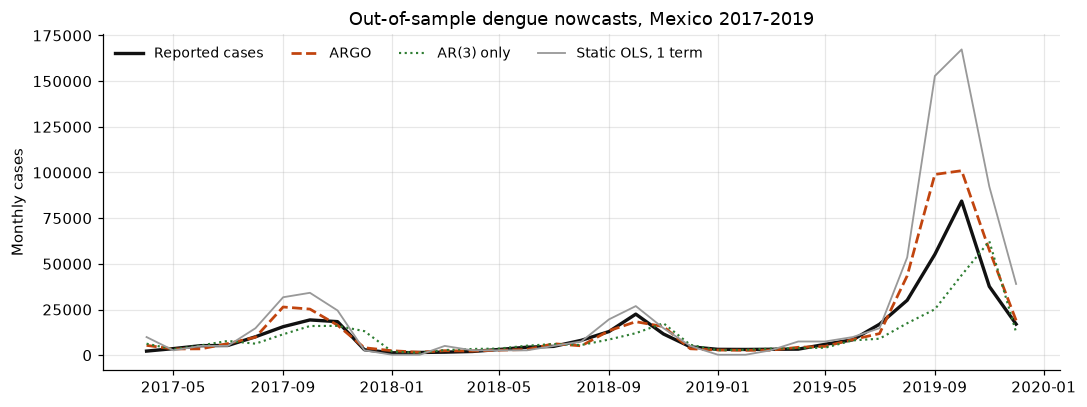

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(truth.index, truth.values, color="#111", lw=2.2, label="Reported cases")
ax.plot(window, pred_argo.loc[window], color="#c1440e", lw=1.8, ls="--", label="ARGO")
ax.plot(window, pred_ar.loc[window],   color="#2e7d32", lw=1.4, ls=":",  label="AR(3) only")
ax.plot(window, pred_static.loc[window], color="#999", lw=1.2, label="Static OLS, 1 term")
ax.set_title("Out-of-sample dengue nowcasts, Mexico 2017-2019")
ax.set_ylabel("Monthly cases"); ax.legend(frameon=False, ncol=4, fontsize=9)
plt.tight_layout(); plt.show()

## Reading the table honestly

The agent will not do this part for you.

**Dynamic training is the single biggest win.** The frozen 24-month fit is more than twice as bad as anything that keeps refitting. Most of the value in the ARGO paper is that one idea, and it is the cheapest thing on the list to implement.

**Search genuinely helps here.** ARGO improves on the autoregression benchmark by about 10% in RMSE and roughly 20% in MAE. The correlation gain is the striking part: AR(3) alone tracks at 0.80, ARGO at 0.97. Autoregression is good at the level and bad at the turns; search is what catches the turns, which is exactly the claim the 2015 paper made.

**But look at what search alone does.** On its own it is worse than autoregression. The signal is real and it is *complementary*, not sufficient. Anyone reporting the search-only model as a success would be overselling.

One caveat I have to state rather than bury: this is **33 evaluation months** on a 24-month rolling window, chosen because it is the longest clean stretch the download offered. That is a small sample, and a 10% margin on 33 points is encouraging rather than conclusive. The honest summary is "the method reproduces and the direction is right," not "ARGO is 10% better than autoregression."

That paragraph is the part I still have to write myself, and it is the part that decides whether the analysis is any good.

## What this cost

Roughly half an hour of prompting. Two live data sources, four prompts, no Python written by me. In 2015 the equivalent was most of a year, and the majority of that year was plumbing: fetching data, aligning dates, wiring cross-validation, making plots legible.

That plumbing is now close to free. What is not free, and what did not get cheaper:

| Still expensive | Now nearly free |
|---|---|
| Noticing the case record has a seven-year hole in it | Downloading and aggregating the record |
| Knowing "confirmed" and "total" cases are different quantities | Joining the two tables |
| Knowing Google Trends thresholds low volume to zero | Handling the zeros once you know |
| Deciding 33 months is a small sample, and saying so | Computing the 10% |
| Choosing dynamic training as the idea worth testing | Implementing the rolling window |

Every item in the left column is domain knowledge, and the agent produced fluent, running, plausible code without any of it.

**Where to point this next.** The transferable object is not the dengue result, it is the shape of the prompt sequence: **download, verify, baseline, add the real method, verify again, compare.** At SISMID a student took an outbreak-detection exercise in this shape and pointed it at West Nile virus in an afternoon. Swap the disease, the geography, the data stream. The scaffold holds.

---

**Next:** [`02_education_reading_group.md`](../02_education_reading_group.md), where the agent is not writing models at all.